![Banner PTI Clima](https://raw.githubusercontent.com/SantanderMetGroup/PTI-Clima-Datalab/devel/aux/Banner-logos-PTIClima-ProyectoServiciosAEMET.png)
# Datalab de la Plataforma Estatal de Servicios Climáticos 
***
> Los cuadernos (Jupyter Notebooks) incluidos en este Datalab muestran ejemplos prácticos para utilizar, transformar y visualizar los conjuntos de datos disponibles en el [almacén de datos](https://pti.climate.ifca.es/data) de la Plataforma Estatal de Servicios Climáticos.
>
> Este trabajo está licenciado bajo una [Licencia Creative Commons Atribución 4.0 Internacional](http://creativecommons.org/licenses/by/4.0).
>
> ![Licencia de Creative Commons](https://i.creativecommons.org/l/by/4.0/88x31.png)

## Guía para el uso del dataset: NEX-GDDP-CMIP6

**M. Iturbide** (Instituto de Física de Cantabria, CSIC-Universidad de Cantabria, Santander, Spain).

En este notebook verás cómo trabajar con el dataset NEX-GDDP-CMIP6 disponible en el Almacén de Datos de la Plataforma Estatal de Servicios Climáticos. Este notebook tiene como objetivo principal facilitar su reutilización y asegurar la reproducibilidad de los productos climáticos. La guía recorre los pasos esenciales para acceder a los datos, definir peticiones de carga, realizar transformaciones básicas y visualizar los resultados.

La Plataforma Virtual de Cálculo ofrece, además, un **notebook de primeros pasos** y una **colección de notebooks temáticos** (p. ej., intercomparación de conjuntos de datos observacionales o cálculo de índices) que puedes consultar para ampliar el uso de las herramientas y profundizar en los análisis a partir de los datos disponibles en el Almacén.

Todo el flujo de trabajo se realiza con ***climate4R***, un framework de librerías en R para la carga, el postprocesamiento y el análisis de datos climáticos.

<img src="https://raw.githubusercontent.com/SantanderMetGroup/climate4R/refs/heads/devel/man/figures/climate4R_logo.svg" alt="Description" width="60" height="40">

***climate4R*** ofrece más funcionalidades de las que se ilustran en este notebook, como **funcionalidades de operaciones espaciales y temporales** o como **interpolación, subsetting o intersección espacial**. Además, brinda funcionalidades para la **corrección de sesgo y downscaling** o funciones específicas para el **cálculo del FWI**. Consulta [Iturbide et al., 2019](https://www.sciencedirect.com/science/article/pii/S1364815218303049?via%3Dihub) y el repositorio de [github de climate4R](https://github.com/SantanderMetGroup/climate4R) para más información.

### Contenido de este cuaderno
1) Carga de librerías
2) Selección de conjuntos de datos  
3) Carga de datos y visualización
4) Cálculo de la señal de cambio climático de la media del multi-modelo

Antes de empezar, o en cualquier momento durante el cuaderno, podemos personalizar el área de visualización de gráficos de la siguiente manera:

In [1]:
library(repr)
# Change plot size 
options(repr.plot.width=8, repr.plot.height=5)

Empezamos asignando a la JVM (Máquina Virtual de Java) la memoria que estimemos necesaria para la carga de datos que realizaremos.

In [2]:
options(java.parameters = "-Xmx10g")

### 1. Carga de librerías

Para las operaciones que se llevan a cabo en este notebook solo necesitaremos tres librerías de ***climate4R***: `loadeR` para la carga de datos, `transformeR` para calcular agregaciones temporales y extraer subconjuntos de información, y `visualizeR para` la representación gráfica de los resultados.

In [3]:
library(loadeR)
library(transformeR)
library(visualizeR)
library(magrittr)

Loading required package: rJava

Loading required package: loadeR.java

Java version 22x amd64 by N/A detected

NetCDF Java Library v4.6.0-SNAPSHOT (23 Apr 2015) loaded and ready

Loading required package: climate4R.UDG

climate4R.UDG version 0.2.6 (2023-06-26) is loaded

Please use 'citation("climate4R.UDG")' to cite this package.

loadeR version 1.8.1 (2023-06-22) is loaded


Get the latest stable version (1.8.2) using <devtools::install_github(c('SantanderMetGroup/climate4R.UDG','SantanderMetGroup/loadeR'))>

Please use 'citation("loadeR")' to cite this package.




    _______   ____  ___________________  __  ________ 
   / ___/ /  / /  |/  / __  /_  __/ __/ / / / / __  / 
  / /  / /  / / /|_/ / /_/ / / / / __/ / /_/ / /_/_/  
 / /__/ /__/ / /  / / __  / / / / /__ /___  / / \ \ 
 \___/____/_/_/  /_/_/ /_/ /_/  \___/    /_/\/   \_\ 
 
      github.com/SantanderMetGroup/climate4R



transformeR version 2.2.2 (2023-10-26) is loaded


Get the latest stable version (2.2.5) using <devtools::install_github('SantanderMetGroup/transformeR')>

Please see 'citation("transformeR")' to cite this package.

visualizeR version 1.6.4 (2023-10-26) is loaded

Please see 'citation("visualizeR")' to cite this package.



Sin embargo, el software incluye todo el framework *climate4R* y otras bibliotecas útiles. Por ejemplo, incluye la potente biblioteca de gráficos `lattice` o la biblioteca `magrittr` para operaciones en tuberías (a través de `%>%`).

In [4]:
library(lattice)
library(magrittr)

### 2. Selección de conjuntos de datos  

El inventario `data_inventory.csv` cataloga la lista de archivos del Almacén de datos de la PTI-Clima.

Basta con leer este archivo mediante `read.csv` para obtener el `data.frame` que contiene esta información.

In [5]:
df <- read.csv("../../data_inventory.csv")

A continuación mostramos el cabecero del inventario.

In [6]:
head(df)

,dataset,type,access,source,provider,experiment,frequency,endpoint,dictionary
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,AEMET-ROCIO-IBEB-regular_Iberia_day,observations,opendap,AEMET-ROCIO-IBEB-regular,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/AEMET-ROCIO-IBEB/Iberia/day/AEMET-ROCIO-IBEB_Iberia_day.ncml,../../Harmonization_dictionaries/AEMET-ROCIO-IBEB-regular.dic
2,AEMET-ROCIO-CAN-regular_Canarias_day,observations,opendap,AEMET-ROCIO-CAN-regular,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/AEMET-ROCIO-CAN/Canarias/day/AEMET-ROCIO-CAN_Canarias_day.ncml,../../Harmonization_dictionaries/AEMET-ROCIO-CAN-regular.dic
3,CHELSA-W5E5v1.0_Canarias_day,observations,opendap,CHELSA-W5E5v1.0,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/CHELSA-W5E5v1.0/Canarias/day/CHELSA-W5E5v1.0_Canarias_day.ncml,../../Harmonization_dictionaries/CHELSA-W5E5v1.0.dic
4,CHELSA-W5E5v1.0_Iberia_day,observations,opendap,CHELSA-W5E5v1.0,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/CHELSA-W5E5v1.0/Iberia/day/CHELSA-W5E5v1.0_Iberia_day.ncml,../../Harmonization_dictionaries/CHELSA-W5E5v1.0.dic
5,PTI-grid-v0_Canarias_day,observations,opendap,PTI-grid-v0,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v0/Canarias/day/PTI-grid-v0_Canarias_day.ncml,../../Harmonization_dictionaries/PTI-grid-v0.dic
6,PTI-grid-v0_Iberia_day,observations,opendap,PTI-grid-v0,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v0/Iberia/day/PTI-grid-v0_Iberia_day.ncml,../../Harmonization_dictionaries/PTI-grid-v0.dic


Para encontrar fácilmente el *dataset* que nos interesa, usaremos la función `subset`, filtrando por `source == "NEX-GDDP-CMIP6"` y restringiendo al dominio ibérico mediante `grepl("Iberia", dataset)`.

De este modo obtenemos una **lista de múltiples *datasets***: uno por cada **GCM** y por cada **escenario** de CMIP6 (`"historical"`, `"ssp126"`, `"ssp245"`, `"ssp370"`, `"ssp585"`).

In [7]:
subset(df, source == "NEX-GDDP-CMIP6" & grepl("Iberia", dataset)) 

,dataset,type,access,source,provider,experiment,frequency,endpoint,dictionary
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
287,ACCESS-CM2_r1i1p1f1_historical_Iberia_day_gn,projections,opendap,NEX-GDDP-CMIP6,NCCS,historical,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/PROJECTIONS/NEX-GDDP-CMIP6/v2/Iberia/day/ACCESS-CM2/historical/r1i1p1f1/ACCESS-CM2_r1i1p1f1_historical_Iberia_day_gn.ncml,
288,ACCESS-CM2_r1i1p1f1_ssp126_Iberia_day_gn,projections,opendap,NEX-GDDP-CMIP6,NCCS,ssp126,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/PROJECTIONS/NEX-GDDP-CMIP6/v2/Iberia/day/ACCESS-CM2/ssp126/r1i1p1f1/ACCESS-CM2_r1i1p1f1_ssp126_Iberia_day_gn.ncml,
289,ACCESS-CM2_r1i1p1f1_ssp245_Iberia_day_gn,projections,opendap,NEX-GDDP-CMIP6,NCCS,ssp245,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/PROJECTIONS/NEX-GDDP-CMIP6/v2/Iberia/day/ACCESS-CM2/ssp245/r1i1p1f1/ACCESS-CM2_r1i1p1f1_ssp245_Iberia_day_gn.ncml,
290,ACCESS-CM2_r1i1p1f1_ssp370_Iberia_day_gn,projections,opendap,NEX-GDDP-CMIP6,NCCS,ssp370,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/PROJECTIONS/NEX-GDDP-CMIP6/v2/Iberia/day/ACCESS-CM2/ssp370/r1i1p1f1/ACCESS-CM2_r1i1p1f1_ssp370_Iberia_day_gn.ncml,
291,ACCESS-CM2_r1i1p1f1_ssp585_Iberia_day_gn,projections,opendap,NEX-GDDP-CMIP6,NCCS,ssp585,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/PROJECTIONS/NEX-GDDP-CMIP6/v2/Iberia/day/ACCESS-CM2/ssp585/r1i1p1f1/ACCESS-CM2_r1i1p1f1_ssp585_Iberia_day_gn.ncml,
292,ACCESS-ESM1-5_r1i1p1f1_historical_Iberia_day_gn,projections,opendap,NEX-GDDP-CMIP6,NCCS,historical,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/PROJECTIONS/NEX-GDDP-CMIP6/v2/Iberia/day/ACCESS-ESM1-5/historical/r1i1p1f1/ACCESS-ESM1-5_r1i1p1f1_historical_Iberia_day_gn.ncml,
293,ACCESS-ESM1-5_r1i1p1f1_ssp126_Iberia_day_gn,projections,opendap,NEX-GDDP-CMIP6,NCCS,ssp126,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/PROJECTIONS/NEX-GDDP-CMIP6/v2/Iberia/day/ACCESS-ESM1-5/ssp126/r1i1p1f1/ACCESS-ESM1-5_r1i1p1f1_ssp126_Iberia_day_gn.ncml,
294,ACCESS-ESM1-5_r1i1p1f1_ssp245_Iberia_day_gn,projections,opendap,NEX-GDDP-CMIP6,NCCS,ssp245,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/PROJECTIONS/NEX-GDDP-CMIP6/v2/Iberia/day/ACCESS-ESM1-5/ssp245/r1i1p1f1/ACCESS-ESM1-5_r1i1p1f1_ssp245_Iberia_day_gn.ncml,
295,ACCESS-ESM1-5_r1i1p1f1_ssp370_Iberia_day_gn,projections,opendap,NEX-GDDP-CMIP6,NCCS,ssp370,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/PROJECTIONS/NEX-GDDP-CMIP6/v2/Iberia/day/ACCESS-ESM1-5/ssp370/r1i1p1f1/ACCESS-ESM1-5_r1i1p1f1_ssp370_Iberia_day_gn.ncml,


### 3. Carga de datos y visualización

El inventario nos indica cuál es el `endpoint` de cada dataset. Es decir, el enlace que necesitamos utilizar para la carga de datos.

Primero concretamos el dataset que queremos analizar y extraemos el elemento *endpoint*. Empezaremos por un único GCM y las simulaciones históricas.

In [8]:
dataset <- subset(df, dataset == "ACCESS-CM2_r1i1p1f1_historical_Iberia_day_gn")

In [9]:
endpoint <- dataset$endpoint

Antes de cargar los datos, conviene revisar el dataset con `dataInventory`. Esta función devuelve un resumen útil para entender qué información contiene y cómo está descrita (variables, unidades y cobertura temporal, entre otros aspectos).

In [10]:
di <- dataInventory(endpoint)

[2026-02-25 17:32:29.207292] Doing inventory ...

[2026-02-25 17:32:29.245834] Opening dataset...

[2026-02-25 17:32:30.242778] The dataset was successfuly opened

[2026-02-25 17:32:30.377373] Retrieving info for 'hurs' (8 vars remaining)

[2026-02-25 17:32:30.481962] Retrieving info for 'huss' (7 vars remaining)

[2026-02-25 17:32:30.573118] Retrieving info for 'pr' (6 vars remaining)

[2026-02-25 17:32:30.642359] Retrieving info for 'rlds' (5 vars remaining)

[2026-02-25 17:32:30.712166] Retrieving info for 'rsds' (4 vars remaining)

[2026-02-25 17:32:30.789271] Retrieving info for 'sfcWind' (3 vars remaining)

[2026-02-25 17:32:30.857101] Retrieving info for 'tas' (2 vars remaining)

[2026-02-25 17:32:30.932773] Retrieving info for 'tasmax' (1 vars remaining)

[2026-02-25 17:32:31.000319] Retrieving info for 'tasmin' (0 vars remaining)

[2026-02-25 17:32:31.068324] Done.



In [11]:
str(di)

List of 9
 $ hurs   :List of 7
  ..$ Description: chr "Near-Surface Relative Humidity"
  ..$ DataType   : chr "float"
  ..$ Shape      : int [1:3] 23741 37 59
  ..$ Units      : chr "%"
  ..$ DataSizeMb : num 207
  ..$ Version    : logi NA
  ..$ Dimensions :List of 3
  .. ..$ time:List of 4
  .. .. ..$ Type      : chr "Time"
  .. .. ..$ TimeStep  : chr "1.0 days"
  .. .. ..$ Units     : chr "days since 1850-01-01"
  .. .. ..$ Date_range: chr "1950-01-01T12:00:00Z - 2014-12-31T12:00:00Z"
  .. ..$ lat :List of 5
  .. .. ..$ Type       : chr "Lat"
  .. .. ..$ Units      : chr "degrees_north"
  .. .. ..$ Values     : num [1:37] 35.1 35.4 35.6 35.9 36.1 ...
  .. .. ..$ Shape      : int 37
  .. .. ..$ Coordinates: chr "lat"
  .. ..$ lon :List of 5
  .. .. ..$ Type       : chr "Lon"
  .. .. ..$ Units      : chr "degrees_east"
  .. .. ..$ Values     : num [1:59] 350 350 350 351 351 ...
  .. .. ..$ Shape      : int 59
  .. .. ..$ Coordinates: chr "lon"
 $ huss   :List of 7
  ..$ Description: ch

Este resumen facilita definir la petición de carga de datos. En este ejemplo, cargamos la precipitación diaria (`pr`). Del periodo completo disponible (véase `Date_range` en el resumen del dataset), solicitaremos un intervalo de 20 años. La carga se realiza con la función `loadGridData`, que permite especificar otros parámetros además de la variable y el periodo; por ejemplo, podemos seleccionar una estación concreta o agregar los datos a escala mensual. En este caso, pedimos la media mensual de los meses de invierno (`c(12, 1:2)`). *NOTA: Esta operación puede tardar unos minutos cuando se trata de conjuntos de datos de alta resolución*.

Como se observa en el resumen del dataset, la precipitación se expresa en unidades de flujo (kg m-2 s-1). Para obtenerla en milímetros (mm) podemos realizar una transformación posterior a la carga o, alternativamente, utilizar un diccionario de armonización (en este caso, Harmonization_dictionaries/NEX-GDDP-CMIP6.dic) para que los datos se devuelvan en las unidades que climate4R define como estándar. Para más detalles sobre el uso de diccionarios en la armonización de datos, consulta el notebook de primeros pasos (primeros_pasos_R.ipynb).

In [12]:
pr <- loadGridData(dataset = endpoint,
                           var = "pr",
                           season = c(12, 1:2),
                           years = 1991:2010,
                           aggr.m = "mean",
                           dictionary = "../../Harmonization_dictionaries/NEX-GDDP-CMIP6.dic")

[2026-02-25 17:32:31.323535] Defining harmonization parameters for variable "pr"

[2026-02-25 17:32:31.344893] Opening dataset...

[2026-02-25 17:32:31.477413] The dataset was successfuly opened

[2026-02-25 17:32:31.483862] Defining geo-location parameters

[2026-02-25 17:32:31.587228] Defining time selection parameters

NOTE: Daily data will be monthly aggregated

[2026-02-25 17:32:31.805092] Retrieving data subset ...

[2026-02-25 17:32:37.58806] Done



El objeto resultante es lo que denominamos *grid de climate4R*. Se trata de una lista con los elementos "Variable", "Data", "xyCoords" y "Dates". Es posible extraer cada uno de estos componentes y transformarlos mediante operaciones básicas de R, sin embargo, las librerías de climate4R están diseñadas para trabajar de forma transparente con la estructura completa.

In [13]:
str(pr)

List of 4
 $ Variable:List of 2
  ..$ varName: chr "pr"
  ..$ level  : NULL
  ..- attr(*, "use_dictionary")= logi TRUE
  ..- attr(*, "description")= chr "Precipitation"
  ..- attr(*, "units")= chr "mm"
  ..- attr(*, "longname")= chr "total precipitation amount"
  ..- attr(*, "daily_agg_cellfun")= chr "none"
  ..- attr(*, "monthly_agg_cellfun")= chr "mean"
  ..- attr(*, "verification_time")= chr "none"
 $ Data    : num [1:60, 1:37, 1:59] NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN ...
  ..- attr(*, "dimensions")= chr [1:3] "time" "lat" "lon"
 $ xyCoords:List of 2
  ..$ x: num [1:59] -10 -9.75 -9.5 -9.25 -9 -8.75 -8.5 -8.25 -8 -7.75 ...
  ..$ y: num [1:37] 35.1 35.4 35.6 35.9 36.1 ...
  ..- attr(*, "projection")= chr "LatLonProjection"
  ..- attr(*, "resX")= num 0.25
  ..- attr(*, "resY")= num 0.25
 $ Dates   :List of 2
  ..$ start: chr [1:60] "1990-12-01 GMT" "1991-01-01 GMT" "1991-02-01 GMT" "1991-12-01 GMT" ...
  ..$ end  : chr [1:60] "1991-01-01 GMT" "1991-02-01 GMT" "1991-03-01 GMT" "19

*climate4R* incluye múltiples funciones de transformación para agregar datos (temporal y espacialmente), extraer subconjuntos, modificar unidades, etc. A continuación se muestran algunos ejemplos. 

Para obtener el promedio temporal a lo largo de todo el periodo del grid, la función más directa es `climatology`.

In [14]:
pr.clim <- climatology(pr)

[2026-02-25 17:32:37.643179] - Computing climatology...

[2026-02-25 17:32:37.660333] - Done.



Para agregar los datos anualmente usaremos `aggregateGrid` con el argumento `aggr.y`.

In [15]:
pr.annual <- aggregateGrid(pr, aggr.y = list(FUN = "mean", na.rm = T))

[2026-02-25 17:32:37.68027] Performing annual aggregation...

[2026-02-25 17:32:38.016388] Done.



Para extraer localidades o subconjuntos espaciales usaremos `subsetGrid` definiendo los argumentos `lonLim` y `latLim`. Para extraer una subregión, `latLim` y `lonLim` se definen como vectores de dos elementos que definen los límites de la región de interés. En este ejemplo, extraemos la información para localidades puntuales, por lo tanto se asigna un único valor a `latLim` y a `lonLim`. 

In [16]:
gasteiz <- subsetGrid(pr.annual, latLim = 42.85, lonLim = -2.67)
murcia <- subsetGrid(pr.annual, latLim = 37.99, lonLim = -1.13) 
lugo <- subsetGrid(pr.annual, latLim = 43.01, lonLim = -7.56)

Las principales funciones de visualización son `temporalPlot` (series temporales) y `spatialPlot` (mapas).

pad applied on the interval: year

pad applied on the interval: year

pad applied on the interval: year



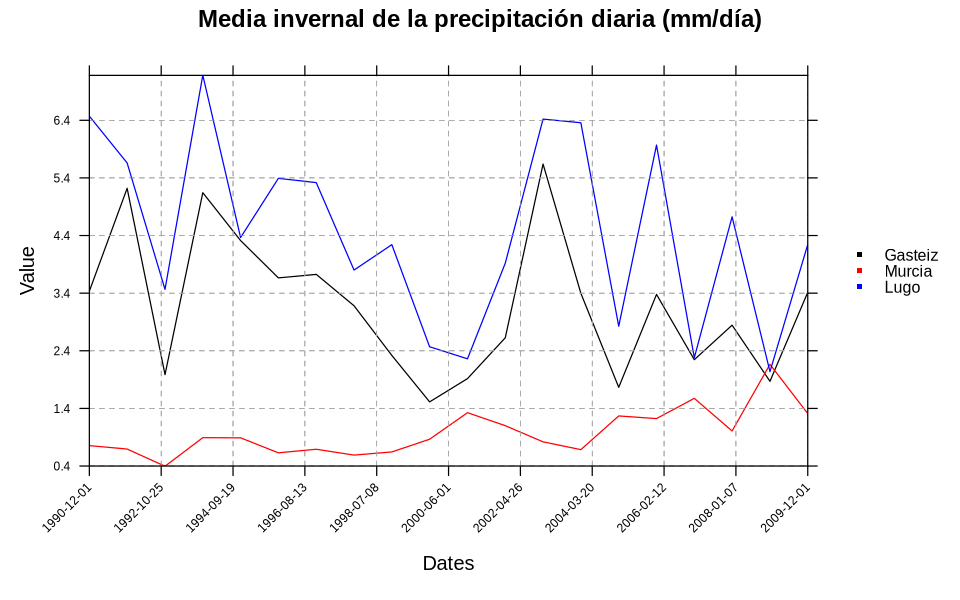

In [17]:
temporalPlot("Gasteiz" = gasteiz, "Murcia" = murcia, "Lugo" = lugo, 
             xyplot.custom = list(main = "Media invernal de la precipitación diaria (mm/día)"))

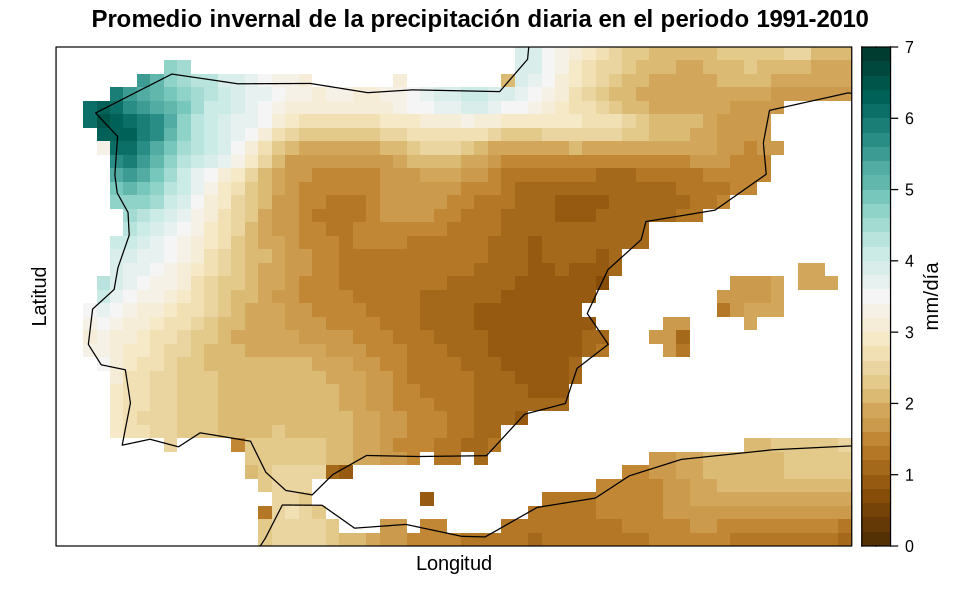

In [18]:
spatialPlot(pr.clim, 
            at = seq(0, 7, 0.2),
            set.max = 7,
            set.min = 0,
            main= "Promedio invernal de la precipitación diaria en el periodo 1991-2010", 
            backdrop.theme = "coastline", 
            color.theme = "BrBG", 
            colorkey = list(space = "right",
                            title = list("mm/día", cex = 1)
                           ),
            xlab = "Longitud",
            ylab = "Latitud"
           )

En lugar de la media podemos calcular cualquier otro estadístico con `climatology` definiendo la función de agregación (parámetro `clim.fun`), por ejemplo, podemos visualizar el percentil 90 utilizando previamente la función `quantile` (librería `stats` de R) en el cálculo de la climatología.

In [19]:
pr.clim.p90 <- climatology(pr, clim.fun = list(FUN = "quantile", probs = 0.90, na.rm=TRUE))


[2026-02-25 17:32:38.950307] - Computing climatology...

[2026-02-25 17:32:39.251312] - Done.



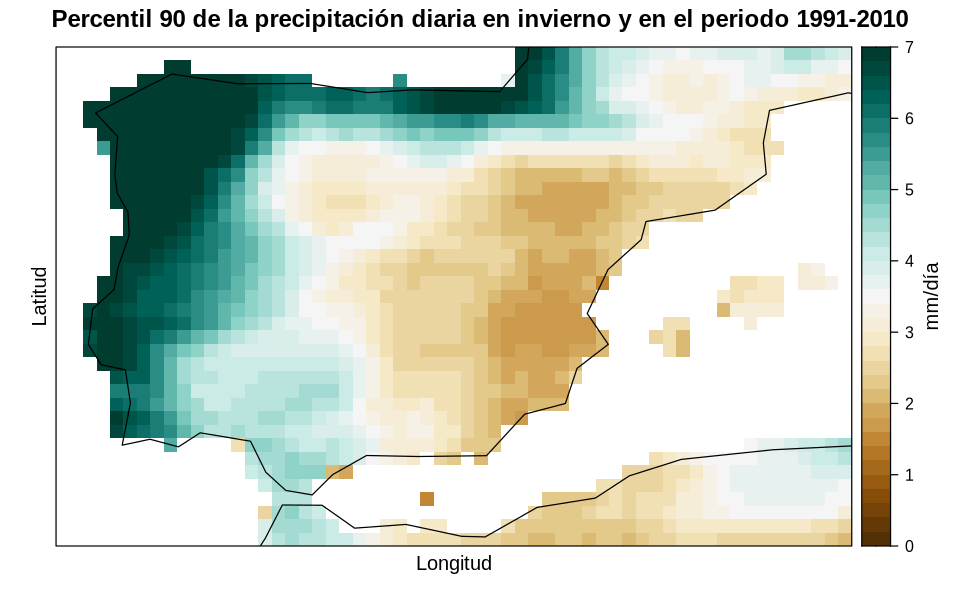

In [20]:
spatialPlot(pr.clim.p90, 
            at = seq(0, 7, 0.2),
            set.max = 7,
            set.min = 0, 
            main = "Percentil 90 de la precipitación diaria en invierno y en el periodo 1991-2010", 
            backdrop.theme = "coastline", 
            color.theme = "BrBG", 
            colorkey = list(space = "right",
                            title = list("mm/día", cex = 1)
                           ),
            xlab = "Longitud",
            ylab = "Latitud"
           )

----
A continuación se repite parte del proceso visto anteriormente, considerando el dataset correspondiente a ***Canarias***. En este caso cargaremos la temperatura máxima de verano. Primero cargamos y transformamos los datos.

In [21]:
dataset.can <- subset(df, dataset == "ACCESS-CM2_r1i1p1f1_historical_Canarias_day_gn")
endpoint.can <- dataset.can$endpoint

tasmax.can <- loadGridData(dataset = endpoint.can,
                           var = "tasmax",
                           season = 6:8,
                           years = 1991:2010,
                           aggr.m = "mean",
                           dictionary = "../../Harmonization_dictionaries/NEX-GDDP-CMIP6.dic")

tasmax.can.clim <- climatology(tasmax.can)
tasmax.can.anual <- aggregateGrid(tasmax.can, aggr.y = list(FUN = "mean", na.rm = T))

[2026-02-25 17:32:39.815073] Defining harmonization parameters for variable "tasmax"

[2026-02-25 17:32:39.851935] Opening dataset...

[2026-02-25 17:32:39.983043] The dataset was successfuly opened

[2026-02-25 17:32:39.988527] Defining geo-location parameters

[2026-02-25 17:32:40.053081] Defining time selection parameters

NOTE: Daily data will be monthly aggregated

[2026-02-25 17:32:40.224683] Retrieving data subset ...

[2026-02-25 17:32:41.522131] Done

[2026-02-25 17:32:41.540529] - Computing climatology...

[2026-02-25 17:32:41.545874] - Done.

[2026-02-25 17:32:41.553324] Performing annual aggregation...

[2026-02-25 17:32:41.592662] Done.



A continuación visualizamos los resultados. En este ejemplo, en lugar de extraer localidades concretas de las islas, representaremos la serie correspondiente a la media regional de todas las islas. La función `temporalPlot` realiza esta aggregación regional de manera automática. 

pad applied on the interval: year



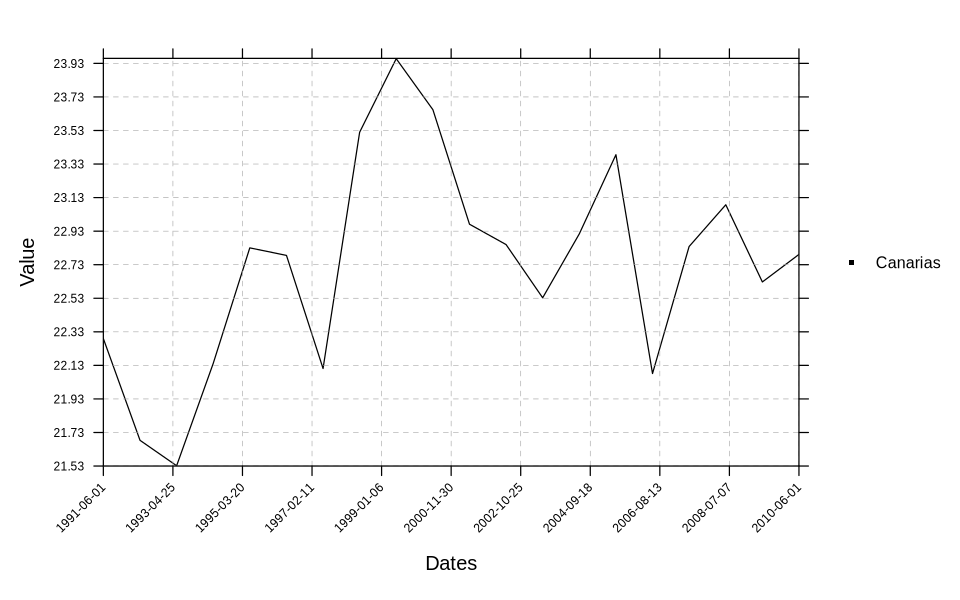

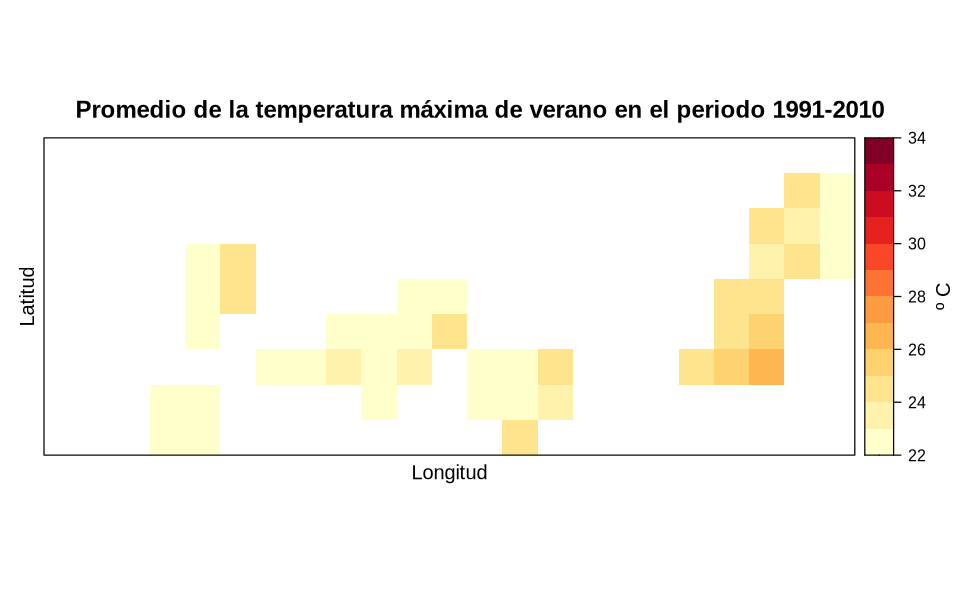

In [22]:
temporalPlot("Canarias" = tasmax.can.anual)

spatialPlot(tasmax.can.clim, 
            at = seq(22, 34, 1),
            set.max = 34,
            set.min = 22,
            main= "Promedio de la temperatura máxima de verano en el periodo 1991-2010", 
            color.theme = "YlOrRd", 
            colorkey = list(space = "right",
                            title = list("º C", cex = 1)
                           ),
            xlab = "Longitud",
            ylab = "Latitud"
           )

### 4. Cálculo de la señal de cambio climático de la media del multi-modelo

En el siguiente ejemplo trabajaremos con el máximo número de modelos (GCMs) disponibles. Diferenciaremos los datasets "historical" de los "ssp585".

In [23]:
datasets.hist <- subset(df, source == "NEX-GDDP-CMIP6" & experiment == "historical" & grepl("Iberia", dataset))[c("dataset", "endpoint", "dictionary")]
datasets.ssp585 <- subset(df, source == "NEX-GDDP-CMIP6" & experiment == "ssp585" & grepl("Iberia", dataset))[c("dataset", "endpoint", "dictionary")]

In [24]:
head(datasets.hist)
head(datasets.ssp585)

,dataset,endpoint,dictionary
,<chr>,<chr>,<chr>
287,ACCESS-CM2_r1i1p1f1_historical_Iberia_day_gn,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/PROJECTIONS/NEX-GDDP-CMIP6/v2/Iberia/day/ACCESS-CM2/historical/r1i1p1f1/ACCESS-CM2_r1i1p1f1_historical_Iberia_day_gn.ncml,
292,ACCESS-ESM1-5_r1i1p1f1_historical_Iberia_day_gn,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/PROJECTIONS/NEX-GDDP-CMIP6/v2/Iberia/day/ACCESS-ESM1-5/historical/r1i1p1f1/ACCESS-ESM1-5_r1i1p1f1_historical_Iberia_day_gn.ncml,
297,BCC-CSM2-MR_r1i1p1f1_historical_Iberia_day_gn,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/PROJECTIONS/NEX-GDDP-CMIP6/v2/Iberia/day/BCC-CSM2-MR/historical/r1i1p1f1/BCC-CSM2-MR_r1i1p1f1_historical_Iberia_day_gn.ncml,
302,CESM2-WACCM_r3i1p1f1_historical_Iberia_day_gn,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/PROJECTIONS/NEX-GDDP-CMIP6/v2/Iberia/day/CESM2-WACCM/historical/r3i1p1f1/CESM2-WACCM_r3i1p1f1_historical_Iberia_day_gn.ncml,
305,CESM2_r4i1p1f1_historical_Iberia_day_gn,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/PROJECTIONS/NEX-GDDP-CMIP6/v2/Iberia/day/CESM2/historical/r4i1p1f1/CESM2_r4i1p1f1_historical_Iberia_day_gn.ncml,
310,CMCC-CM2-SR5_r1i1p1f1_historical_Iberia_day_gn,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/PROJECTIONS/NEX-GDDP-CMIP6/v2/Iberia/day/CMCC-CM2-SR5/historical/r1i1p1f1/CMCC-CM2-SR5_r1i1p1f1_historical_Iberia_day_gn.ncml,


,dataset,endpoint,dictionary
,<chr>,<chr>,<chr>
291,ACCESS-CM2_r1i1p1f1_ssp585_Iberia_day_gn,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/PROJECTIONS/NEX-GDDP-CMIP6/v2/Iberia/day/ACCESS-CM2/ssp585/r1i1p1f1/ACCESS-CM2_r1i1p1f1_ssp585_Iberia_day_gn.ncml,
296,ACCESS-ESM1-5_r1i1p1f1_ssp585_Iberia_day_gn,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/PROJECTIONS/NEX-GDDP-CMIP6/v2/Iberia/day/ACCESS-ESM1-5/ssp585/r1i1p1f1/ACCESS-ESM1-5_r1i1p1f1_ssp585_Iberia_day_gn.ncml,
301,BCC-CSM2-MR_r1i1p1f1_ssp585_Iberia_day_gn,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/PROJECTIONS/NEX-GDDP-CMIP6/v2/Iberia/day/BCC-CSM2-MR/ssp585/r1i1p1f1/BCC-CSM2-MR_r1i1p1f1_ssp585_Iberia_day_gn.ncml,
304,CESM2-WACCM_r3i1p1f1_ssp585_Iberia_day_gn,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/PROJECTIONS/NEX-GDDP-CMIP6/v2/Iberia/day/CESM2-WACCM/ssp585/r3i1p1f1/CESM2-WACCM_r3i1p1f1_ssp585_Iberia_day_gn.ncml,
309,CESM2_r4i1p1f1_ssp585_Iberia_day_gn,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/PROJECTIONS/NEX-GDDP-CMIP6/v2/Iberia/day/CESM2/ssp585/r4i1p1f1/CESM2_r4i1p1f1_ssp585_Iberia_day_gn.ncml,
314,CMCC-CM2-SR5_r1i1p1f1_ssp585_Iberia_day_gn,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/PROJECTIONS/NEX-GDDP-CMIP6/v2/Iberia/day/CMCC-CM2-SR5/ssp585/r1i1p1f1/CMCC-CM2-SR5_r1i1p1f1_ssp585_Iberia_day_gn.ncml,


No todos los datasets comparten necesariamente el mismo conjunto de variables climáticas. A continuación aplicamos `dataInventory` en un bucle, para determinar el subconjunto que comparten la variable `tasmax`.

In [25]:
ind.hist.tx <- lapply(1:nrow(datasets.hist), function(i) "tasmax" %in% names(dataInventory(datasets.hist[i, "endpoint"]))) %>%
                   unlist %>%
                   suppressMessages()
ind.ssp585.tx <- lapply(1:nrow(datasets.ssp585), function(i) "tasmax" %in% names(dataInventory(datasets.ssp585[i, "endpoint"]))) %>%
                   unlist %>%
                   suppressMessages()

In [26]:
datasets.hist.tx <- datasets.hist[ind.hist.tx,]
datasets.ssp585.tx <- datasets.ssp585[ind.ssp585.tx,]

Cabe la posibilidad de que los datasets (GCMs) disponibles para el "historical" no coincidan de manera exacta con el conjunto del "ssp585". Por eso, es recomendable aplicar la intersección que de lugar a conjuntos de GCMs idénticos para ambos escenarios.

In [27]:
datasets <- intersect(
    gsub("historical",".*",datasets.hist.tx$dataset),
    gsub("ssp585",".*",datasets.ssp585.tx$dataset)
    )
ind.hist <- lapply(datasets, grep, datasets.hist.tx$dataset) %>% unlist
ind.ssp585 <- lapply(datasets, grep, datasets.ssp585.tx$dataset) %>% unlist

In [28]:
datasets.hist.def <- datasets.hist.tx[ind.hist,]
datasets.ssp585.def <- datasets.ssp585.tx[ind.ssp585,]

Dado que CMIP6 se compone de múltiples datasets (distintas combinaciones **GCM–escenario**), automatizaremos la carga mediante un **bucle**. Esta operación puede tardar varios minutos.

Intentaremos reducir la carga sin comprometer el análisis. En este caso, no necesitamos datos diarios, así que **agregaremos a escala mensual durante la carga** con el argumento `aggr.m`, extrayendo el **máximo mensual de `tasmax`**.

Además, en el mismo bucle uniremos los resultados en un **grid multi-miembro**. Para ejemplos más sencillos y paso a paso, consulta `primeros_pasos_R.ipynb`.

Primero cargaremos los datos históricos.

In [29]:
tasmax.hist <- lapply(datasets.hist.def$dataset, function(d) {
        dataset.i <- d
        endpoint.i <- subset(datasets.hist.def, dataset == dataset.i)[["endpoint"]]
        dic.i <- subset(datasets.hist.def, dataset == dataset.i)[["dictionary"]]
        message("proccessing...", d)
        loadGridData(dataset = endpoint.i,
                               var = "tasmax",
                               season = 8,
                               years = 1986:2005,
                               aggr.m = "max",
                           dictionary = "../../Harmonization_dictionaries/NEX-GDDP-CMIP6.dic") %>% suppressMessages %>% suppressWarnings
        
    }) %>% bindGrid(dimension = "member") 

proccessing...ACCESS-CM2_r1i1p1f1_historical_Iberia_day_gn

proccessing...ACCESS-ESM1-5_r1i1p1f1_historical_Iberia_day_gn

proccessing...BCC-CSM2-MR_r1i1p1f1_historical_Iberia_day_gn

proccessing...CMCC-ESM2_r1i1p1f1_historical_Iberia_day_gn

proccessing...CNRM-CM6-1_r1i1p1f2_historical_Iberia_day_gr

proccessing...CNRM-ESM2-1_r1i1p1f2_historical_Iberia_day_gr

proccessing...CanESM5_r1i1p1f1_historical_Iberia_day_gn

proccessing...EC-Earth3-Veg-LR_r1i1p1f1_historical_Iberia_day_gr

proccessing...EC-Earth3_r1i1p1f1_historical_Iberia_day_gr

proccessing...FGOALS-g3_r3i1p1f1_historical_Iberia_day_gn

proccessing...GFDL-CM4_r1i1p1f1_historical_Iberia_day_gr2

proccessing...GFDL-ESM4_r1i1p1f1_historical_Iberia_day_gr1

proccessing...GISS-E2-1-G_r1i1p1f2_historical_Iberia_day_gn

proccessing...HadGEM3-GC31-LL_r1i1p1f3_historical_Iberia_day_gn

proccessing...HadGEM3-GC31-MM_r1i1p1f3_historical_Iberia_day_gn

proccessing...INM-CM4-8_r1i1p1f1_historical_Iberia_day_gr1

proccessing...INM-CM5-0_r

Ahora cargaremos los datos de proyecciones futuras (RCP85). Para este caso cargaremos el periodo 2041-2060.

In [30]:
tasmax.ssp585 <- lapply(datasets.ssp585.def$dataset, function(d) {
        dataset.i <- d
        endpoint.i <- subset(datasets.ssp585.def, dataset == dataset.i)[["endpoint"]]
        dic.i <- subset(datasets.ssp585.def, dataset == dataset.i)[["dictionary"]]
        message("proccessing...", d)
        loadGridData(dataset = endpoint.i,
                               var = "tasmax",
                               season = 8,
                               years = 2041:2060,
                               aggr.m = "max",
                           dictionary = "../../Harmonization_dictionaries/NEX-GDDP-CMIP6.dic") %>% suppressMessages %>% suppressWarnings
        
    }) %>% bindGrid(dimension = "member") 

proccessing...ACCESS-CM2_r1i1p1f1_ssp585_Iberia_day_gn

proccessing...ACCESS-ESM1-5_r1i1p1f1_ssp585_Iberia_day_gn

proccessing...BCC-CSM2-MR_r1i1p1f1_ssp585_Iberia_day_gn

proccessing...CMCC-ESM2_r1i1p1f1_ssp585_Iberia_day_gn

proccessing...CNRM-CM6-1_r1i1p1f2_ssp585_Iberia_day_gr

proccessing...CNRM-ESM2-1_r1i1p1f2_ssp585_Iberia_day_gr

proccessing...CanESM5_r1i1p1f1_ssp585_Iberia_day_gn

proccessing...EC-Earth3-Veg-LR_r1i1p1f1_ssp585_Iberia_day_gr

proccessing...EC-Earth3_r1i1p1f1_ssp585_Iberia_day_gr

proccessing...FGOALS-g3_r3i1p1f1_ssp585_Iberia_day_gn

proccessing...GFDL-CM4_r1i1p1f1_ssp585_Iberia_day_gr2

proccessing...GFDL-ESM4_r1i1p1f1_ssp585_Iberia_day_gr1

proccessing...GISS-E2-1-G_r1i1p1f2_ssp585_Iberia_day_gn

proccessing...HadGEM3-GC31-LL_r1i1p1f3_ssp585_Iberia_day_gn

proccessing...HadGEM3-GC31-MM_r1i1p1f3_ssp585_Iberia_day_gn

proccessing...INM-CM4-8_r1i1p1f1_ssp585_Iberia_day_gr1

proccessing...INM-CM5-0_r1i1p1f1_ssp585_Iberia_day_gr1

proccessing...IPSL-CM6A-LR_r1i1p1

El resultado son dos grids multi-miembro. Si comprobamos la estructura, veremos que existe una **dimensión `member`**. Definiremos los nombres de estos miembros a partir del conjunto de datasets, utilizando por ejemplo el objeto `datasets.hist.def`.

In [31]:
modelnames <- gsub("_historical.*", "", datasets.hist.def$dataset) %>% print

 [1] "ACCESS-CM2_r1i1p1f1"       "ACCESS-ESM1-5_r1i1p1f1"   
 [3] "BCC-CSM2-MR_r1i1p1f1"      "CMCC-ESM2_r1i1p1f1"       
 [5] "CNRM-CM6-1_r1i1p1f2"       "CNRM-ESM2-1_r1i1p1f2"     
 [7] "CanESM5_r1i1p1f1"          "EC-Earth3-Veg-LR_r1i1p1f1"
 [9] "EC-Earth3_r1i1p1f1"        "FGOALS-g3_r3i1p1f1"       
[11] "GFDL-CM4_r1i1p1f1"         "GFDL-ESM4_r1i1p1f1"       
[13] "GISS-E2-1-G_r1i1p1f2"      "HadGEM3-GC31-LL_r1i1p1f3" 
[15] "HadGEM3-GC31-MM_r1i1p1f3"  "INM-CM4-8_r1i1p1f1"       
[17] "INM-CM5-0_r1i1p1f1"        "IPSL-CM6A-LR_r1i1p1f1"    
[19] "KACE-1-0-G_r1i1p1f1"       "KIOST-ESM_r1i1p1f1"       
[21] "MIROC-ES2L_r1i1p1f2"       "MIROC6_r1i1p1f1"          
[23] "MPI-ESM1-2-HR_r1i1p1f1"    "MPI-ESM1-2-LR_r1i1p1f1"   
[25] "MRI-ESM2-0_r1i1p1f1"       "NESM3_r1i1p1f1"           
[27] "NorESM2-LM_r1i1p1f1"       "NorESM2-MM_r1i1p1f1"      
[29] "TaiESM1_r1i1p1f1"          "UKESM1-0-LL_r1i1p1f2"     


In [32]:
tasmax.hist$Members <- modelnames
tasmax.ssp585$Members <- modelnames

Para calcular la señal de cambio climático que proyectan cada uno de los GCMs, aplicaremos la función `gridArithmetics` a las climatologías.

In [33]:
anom <- gridArithmetics(climatology(tasmax.ssp585), climatology(tasmax.hist), operator = "-")

[2026-02-25 17:38:02.970792] - Computing climatology...

[2026-02-25 17:38:03.482337] - Done.

[2026-02-25 17:38:03.509292] - Computing climatology...

[2026-02-25 17:38:04.273235] - Done.



Visualizamos los mapas de la señal de cambio climático para cada GCM

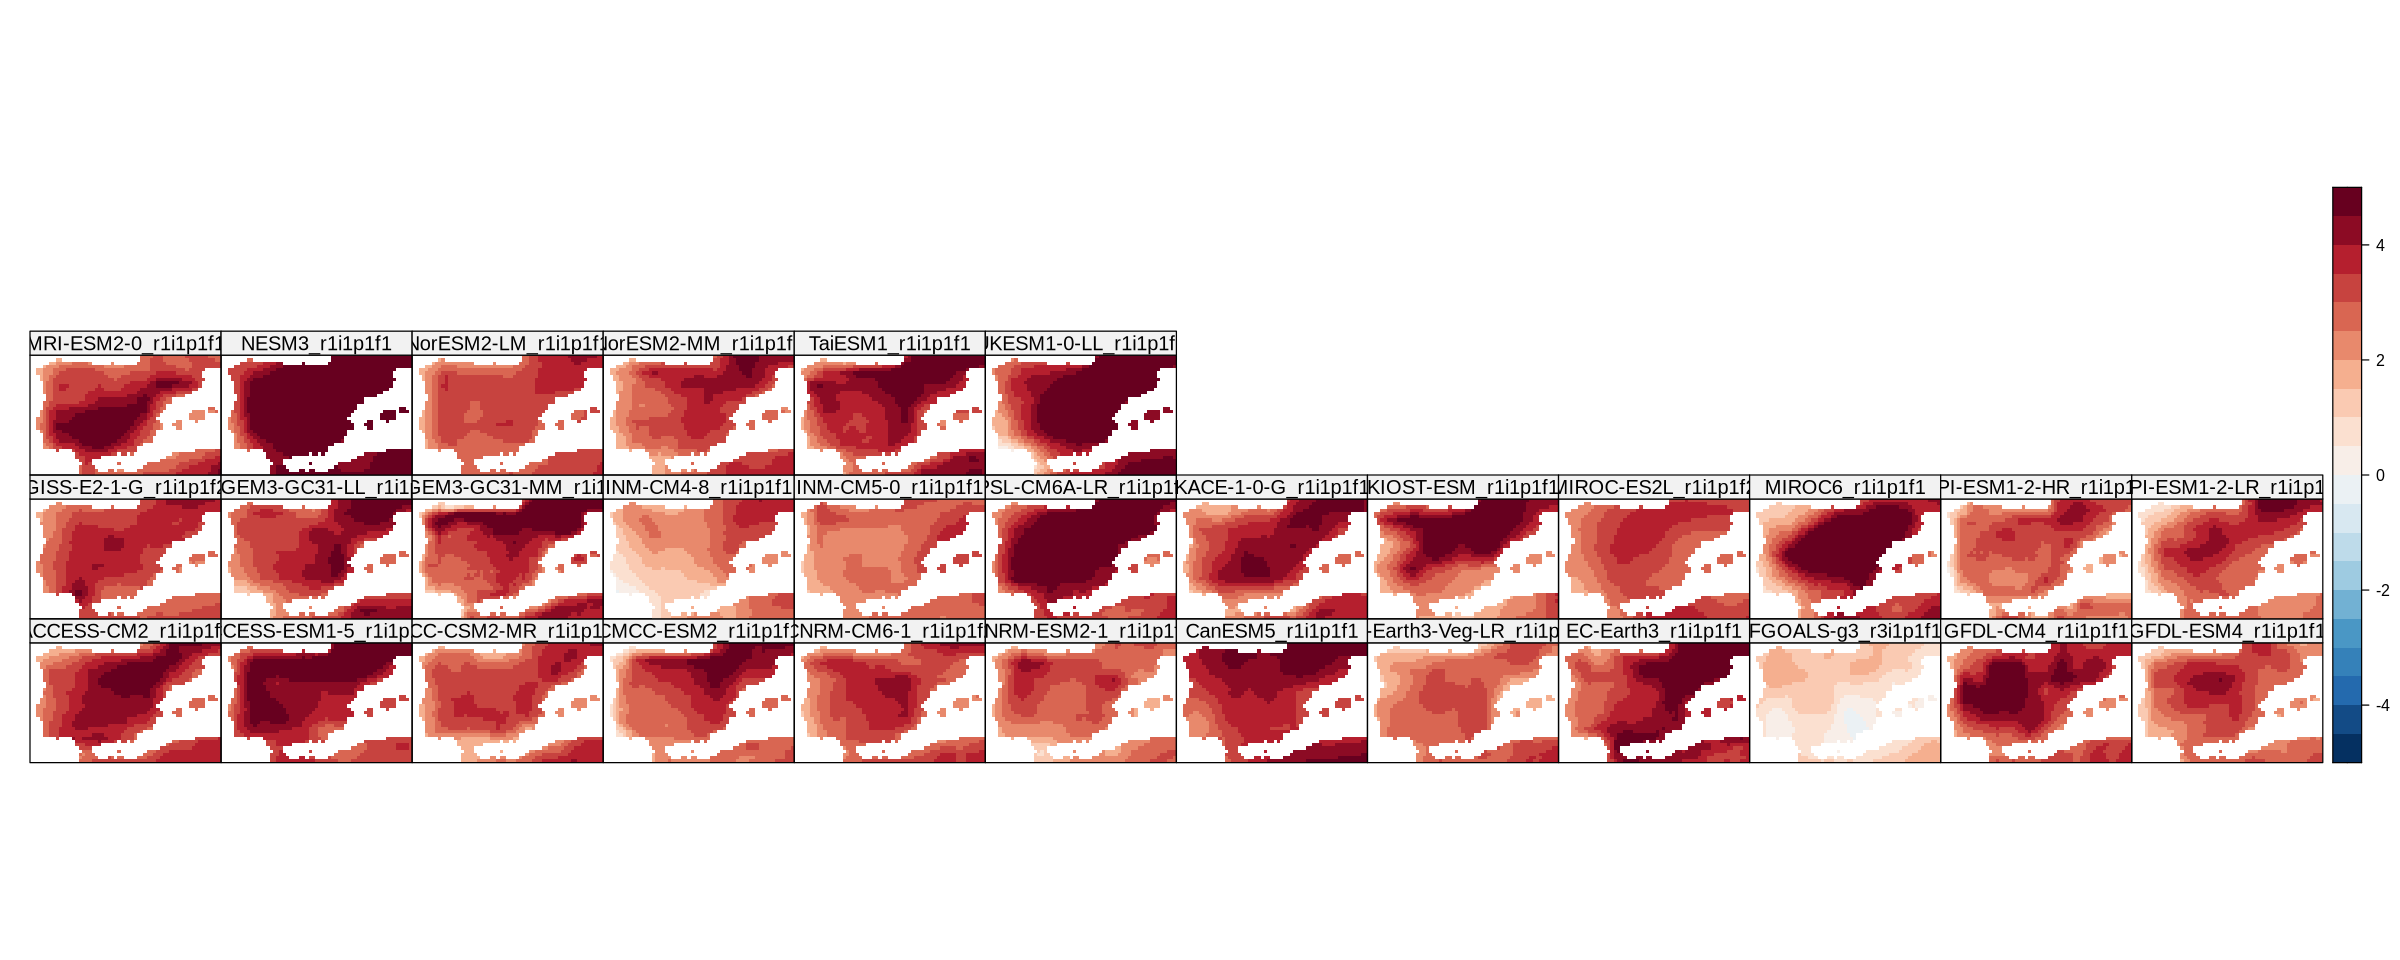

In [34]:
options(repr.plot.width=20, repr.plot.height=8)
spatialPlot(anom, 
            color.theme = "RdBu",
            rev.colors = TRUE,
            at = seq(-5, 5, 0.5),
            set.max = 5,
            set.min = -5,
            layout = c(12, 4),
            strip = strip.custom(factor.levels = anom$Members))

Para calcular la media multi-modelo aplicaremos la función `aggregateGrid` de la siguiente manera.

In [35]:
anom.ens <- aggregateGrid(anom, aggr.mem = list(FUN = "mean", na.rm = T))

[2026-02-25 17:38:05.051776] - Aggregating members...

[2026-02-25 17:38:05.067778] - Done.



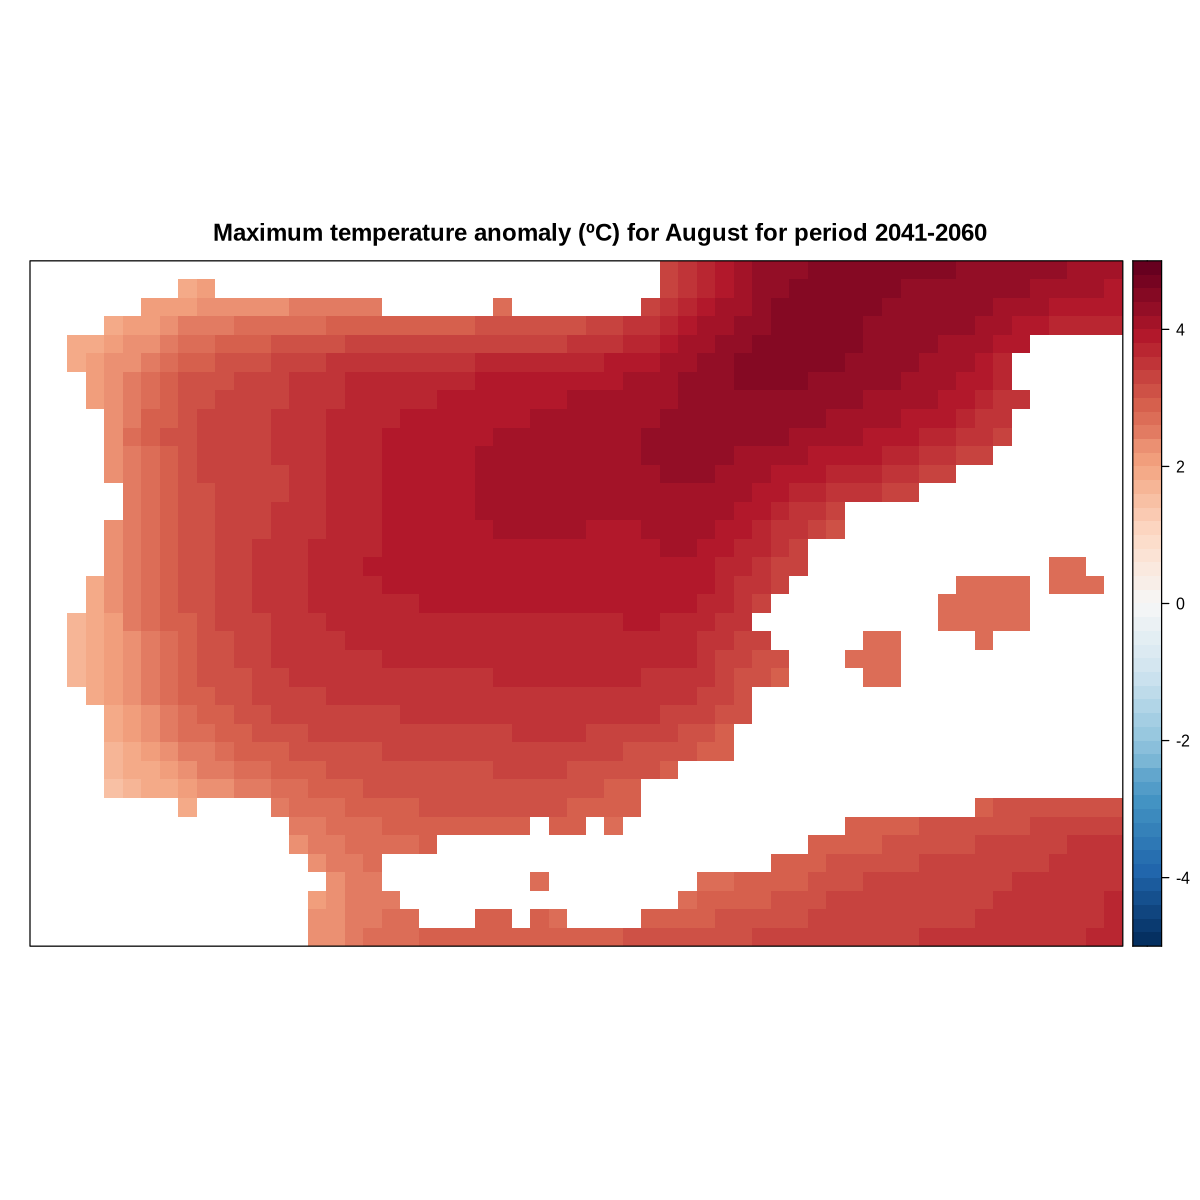

In [36]:
options(repr.plot.width=10, repr.plot.height=10)
spatialPlot(anom.ens, 
            color.theme = "RdBu",
            rev.colors = TRUE,
            at = seq(-5, 5, 0.2),
            set.max = 5,
            set.min = -5,
            main = "Maximum temperature anomaly (ºC) for August for period 2041-2060")

Visualizamos las series temporales inter-anuales.

pad applied on the interval: year

pad applied on the interval: year



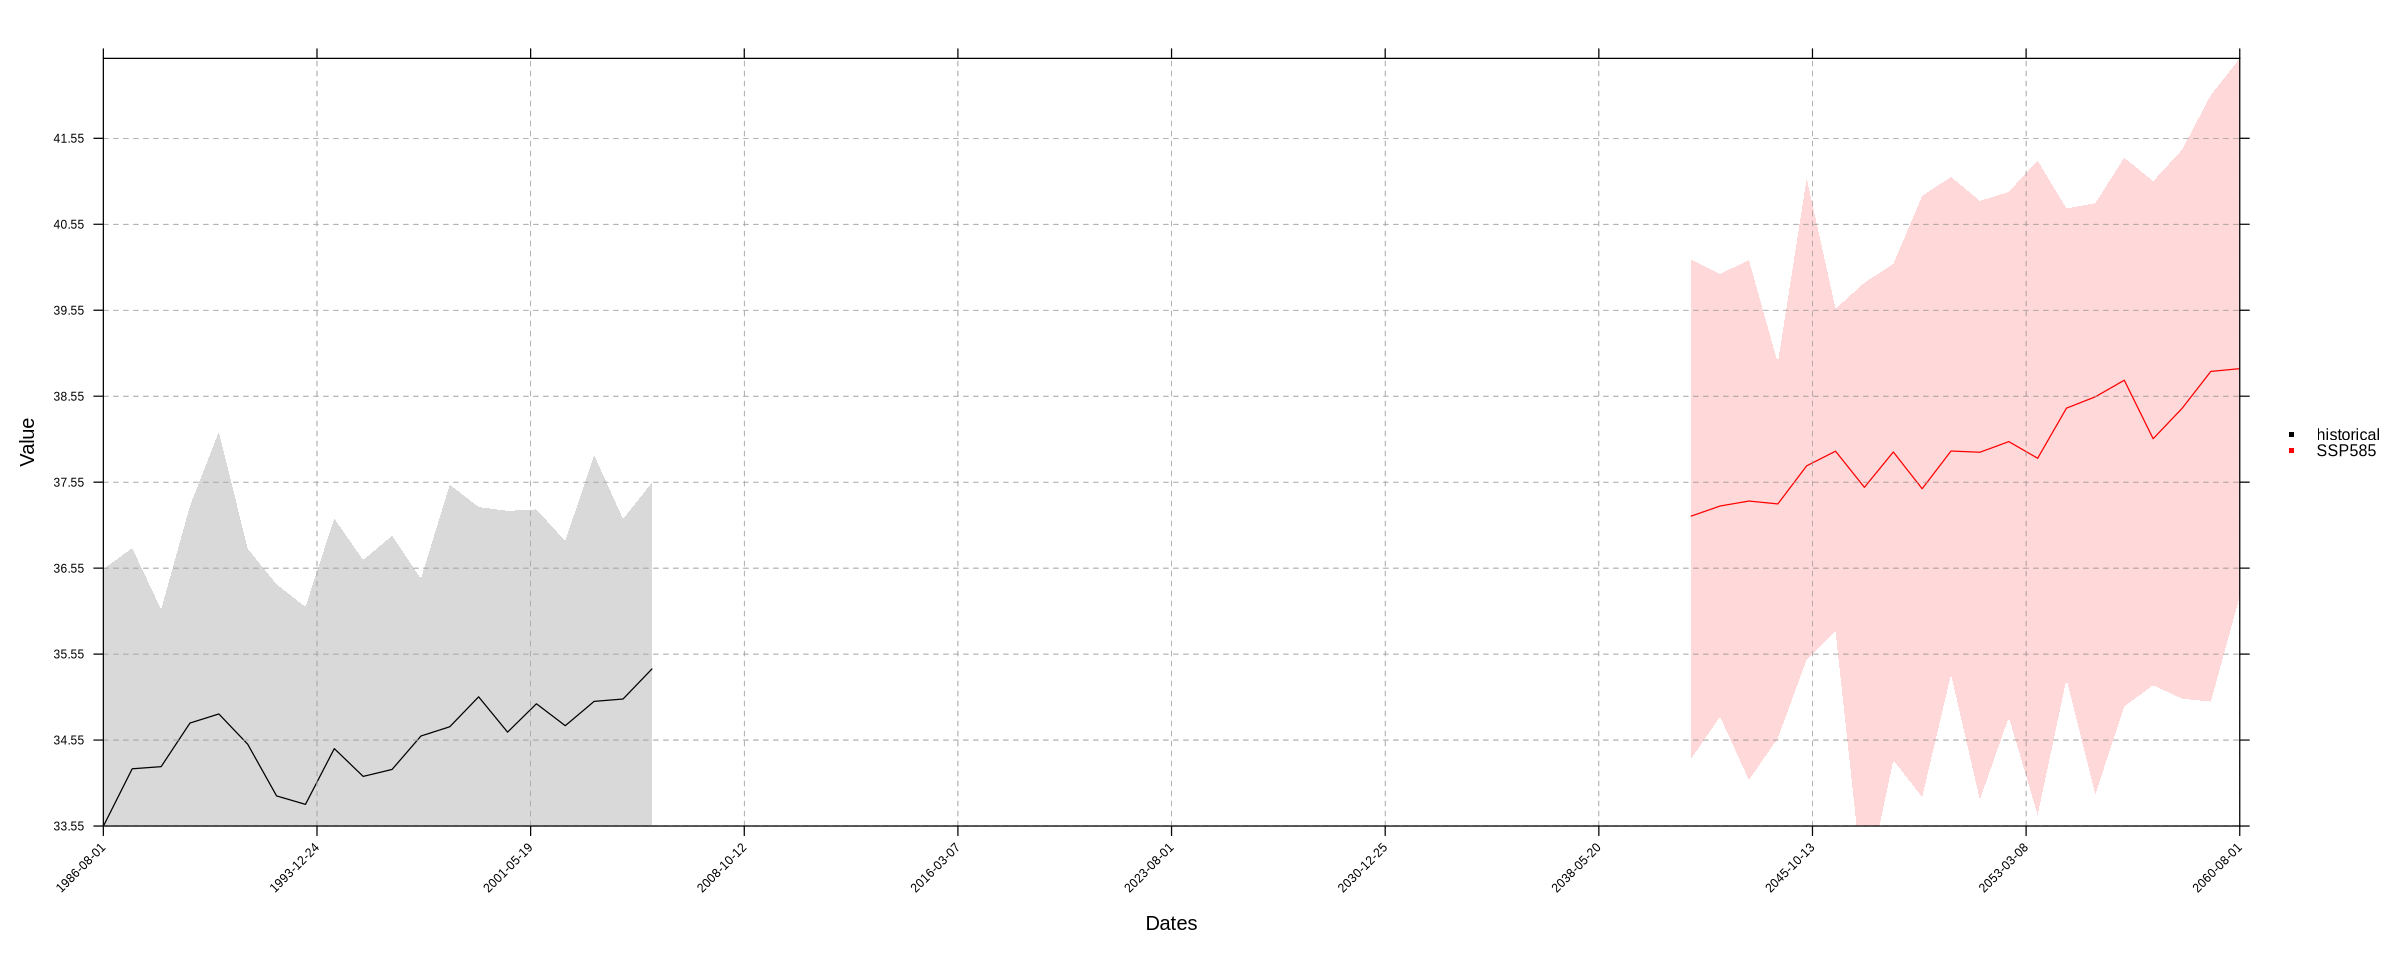

In [37]:
options(repr.plot.width=20, repr.plot.height=8)
temporalPlot("historical" = tasmax.hist, "SSP585" = tasmax.ssp585)

***climate4R*** ofrece más funcionalidades de las que se ilustran en este notebook, como **funcionalidades de operaciones espaciales y temporales** o como **interpolación, subsetting o intersección espacial**. Además, brinda funcionalidades para la **corrección de sesgo y downscaling** o funciones específicas para el **cálculo del FWI**. Consulta [Iturbide et al., 2019](https://www.sciencedirect.com/science/article/pii/S1364815218303049?via%3Dihub) y el repositorio de [github de climate4R](https://github.com/SantanderMetGroup/climate4R) para más información.

La Plataforma Virtual de Cálculo ofrece un **notebook de primeros pasos** y una **colección de notebooks temáticos** (p. ej., intercomparación de conjuntos de datos observacionales o cálculo de índices) que puedes consultar para ampliar el uso de las herramientas y profundizar en los análisis a partir de los datos disponibles en el Almacén.

***

### Session Info

In [38]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.3 LTS

Matrix products: default
BLAS/LAPACK: /opt/conda/envs/climate4r/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8          LC_NUMERIC=C                 
 [3] LC_TIME=en_US.UTF-8           LC_COLLATE=en_US.UTF-8       
 [5] LC_MONETARY=en_US.UTF-8       LC_MESSAGES=en_US.UTF-8      
 [7] LC_PAPER=en_US.UTF-8          LC_NAME=en_US.UTF-8          
 [9] LC_ADDRESS=en_US.UTF-8        LC_TELEPHONE=en_US.UTF-8     
[11] LC_MEASUREMENT=en_US.UTF-8    LC_IDENTIFICATION=en_US.UTF-8

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] lattice_0.22-6      magrittr_2.0.3      visualizeR_1.6.4   
[4] transformeR_2.2.2   loadeR_1.8.1        climate4R.UDG_0.2.6
[7] loadeR.java_1.1.1   rJava_1.0-11        repr_1.1.7         

loaded via 